In [11]:
import xarray as xr
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
data_dir = "../data/NLDAS3"
files = sorted(glob.glob(os.path.join(data_dir, "NLDAS_FOR0010_D.A*.nc")))

# Define the Midwest subset coordinates
midwest_lat_slice = slice(36, 43)
midwest_lon_slice = slice(-98, -85)

# Define thresholds for calculations
GDD_BASE_TEMP_C = 10    # Growing Degree Days base temperature in Celsius
HSD_THRESHOLD_C = 30   # Heat Stress Days threshold in Celsius
FROST_THRESHOLD_C = 0  # Frost Days threshold in Celsius

In [12]:
# --- Data Loading and Preprocessing ---
if not files:
    print(f"Error: No NLDAS files found in {data_dir} with pattern NLDAS_FOR0010_D.A*.nc")
    exit()

print("Opening NLDAS files and subsetting...")

ds = xr.open_mfdataset(files, combine='by_coords', chunks={'time': 1})
ds_subset = ds
# ds_subset = ds.sel(lat=midwest_lat_slice, lon=midwest_lon_slice)

# Convert to degC and add variables to ds_subset
ds_subset['tasmin_C'] = ds_subset['Tair_min'] - 273.15
ds_subset['tasmin_C'].attrs['units'] = 'degC'
ds_subset['tasmin_C'].attrs['long_name'] = 'Daily minimum air temperature in Celsius'

ds_subset['tasmax_C'] = ds_subset['Tair_max'] - 273.15
ds_subset['tasmax_C'].attrs['units'] = 'degC'
ds_subset['tasmax_C'].attrs['long_name'] = 'Daily maximum air temperature in Celsius'

ds_subset['tas_C'] = (ds_subset['tasmin_C'] + ds_subset['tasmax_C']) / 2
ds_subset['tas_C'].attrs['units'] = 'degC'
ds_subset['tas_C'].attrs['long_name'] = 'Daily mean air temperature in Celsius'

Opening NLDAS files and subsetting...


In [13]:
# --- Sanity Check on Subsetted Data ---

print("\n--- Sanity Check on Subsetted Data ---")
nan_count_subset = ds_subset['tas_C'].isnull().sum().compute().item()
total_elements_subset = ds_subset['tas_C'].size
print(f"NaNs in tas_C in SUBSETTED dataset: {nan_count_subset}")
print(f"Total elements in tas_C in SUBSETTED dataset: {total_elements_subset}")
print(f"Percentage NaNs in Subset: { (nan_count_subset / total_elements_subset) * 100:.2f}%")

if nan_count_subset > 0 and nan_count_subset == total_elements_subset:
    print("WARNING: Subset still appears to be all NaNs or empty. Review subset coordinates.")
    exit() # Exit if the core data is still all NaNs


--- Sanity Check on Subsetted Data ---


In [ ]:
# --- Manual Calculation of Indicators ---
print("\nCalculating indicators manually...")

# 1. Growing Degree Days (GDD)
# GDD = sum(max(0, T_mean - T_base))
gdd_daily_contribution = np.maximum(0, ds_subset['tas_C'] - GDD_BASE_TEMP_C)
gdd_monthly = gdd_daily_contribution.resample(time='MS').sum(dim='time', skipna=True).compute()
gdd_monthly.name = 'gdd'
gdd_monthly.attrs['units'] = 'degC.days'
gdd_monthly.attrs['long_name'] = f'Monthly Growing Degree Days (base {GDD_BASE_TEMP_C}°C)'

# 2. Heat Stress Days (HSD)
# HSD = sum(1 if T_max > T_thresh else 0)
hsd_daily_flag = (ds_subset['tasmax_C'] > HSD_THRESHOLD_C).astype(int)
hsd_monthly = hsd_daily_flag.resample(time='MS').sum(dim='time', skipna=True).compute()
hsd_monthly.name = 'hsd'
hsd_monthly.attrs['units'] = 'days'
hsd_monthly.attrs['long_name'] = f'Monthly Heat Stress Days (max temp > {HSD_THRESHOLD_C}°C)'

# 3. Frost Days
# Frost Days = sum(1 if T_min < T_thresh else 0)
frost_daily_flag = (ds_subset['tasmin_C'] < FROST_THRESHOLD_C).astype(int)
frost_monthly = frost_daily_flag.resample(time='MS').sum(dim='time', skipna=True).compute()
frost_monthly.name = 'frost_days'
frost_monthly.attrs['units'] = 'days'
frost_monthly.attrs['long_name'] = f'Monthly Frost Days (min temp < {FROST_THRESHOLD_C}°C)'



Calculating indicators manually...


In [ ]:
# Pick a central point in your subsetted region for detailed inspection
sample_lat_val = 38.5
sample_lon_val = -94.5

# Get the nearest grid point for the chosen sample lat/lon
# Use .sel with method='nearest' for the spatial dimensions
# Use isel(time=0) to get the first month's result (December 2023)
try:
    gdd_point = gdd_monthly.sel(lat=sample_lat_val, lon=sample_lon_val, method='nearest').isel(time=0).item()
    hsd_point = hsd_monthly.sel(lat=sample_lat_val, lon=sample_lon_val, method='nearest').isel(time=0).item()
    frost_point = frost_monthly.sel(lat=sample_lat_val, lon=sample_lon_val, method='nearest').isel(time=0).item()

    print(f"Sample point ({gdd_monthly.lat.sel(lat=sample_lat_val, method='nearest').item():.2f}, "
          f"{gdd_monthly.lon.sel(lon=sample_lon_val, method='nearest').item():.2f}) for December 2023:")
    print(f"  GDD (base {GDD_BASE_TEMP_C}C): {gdd_point:.2f} degC.days")
    print(f"  HSD (max > {HSD_THRESHOLD_C}C): {hsd_point:.0f} days")
    print(f"  Frost Days (min < {FROST_THRESHOLD_C}C): {frost_point:.0f} days")

except Exception as e:
    print(f"Could not retrieve sample point values. Error: {e}")
    print("This might happen if the output is entirely NaN/empty after computation.")

# Print average values for the first month over the subset
if not gdd_monthly.isnull().all().compute():
    print(f"\nAverage GDD (base {GDD_BASE_TEMP_C}C) over subset for first month: "
          f"{gdd_monthly.isel(time=0).mean().item():.2f} degC.days")
else:
    print("\nAverage GDD: All NaNs.")

if not hsd_monthly.isnull().all().compute():
    print(f"Average HSD (max > {HSD_THRESHOLD_C}C) over subset for first month: "
          f"{hsd_monthly.isel(time=0).mean().item():.2f} days")
else:
    print("Average HSD: All NaNs.")

if not frost_monthly.isnull().all().compute():
    print(f"Average Frost Days (min < {FROST_THRESHOLD_C}C) over subset for first month: "
          f"{frost_monthly.isel(time=0).mean().item():.2f} days")
else:
    print("Average Frost Days: All NaNs.")




--- Manual Calculation Result Summary ---
Sample point (38.51, -94.50) for December 2023:
  GDD (base 0C): 124.94 degC.days
  HSD (max > 30C): 0 days
  Frost Days (min < 0C): 12 days

Average GDD (base 0C) over subset for first month: 28.92 degC.days
Average HSD (max > 30C) over subset for first month: 0.22 days
Average Frost Days (min < 0C) over subset for first month: 5.85 days



Plotting derived values...


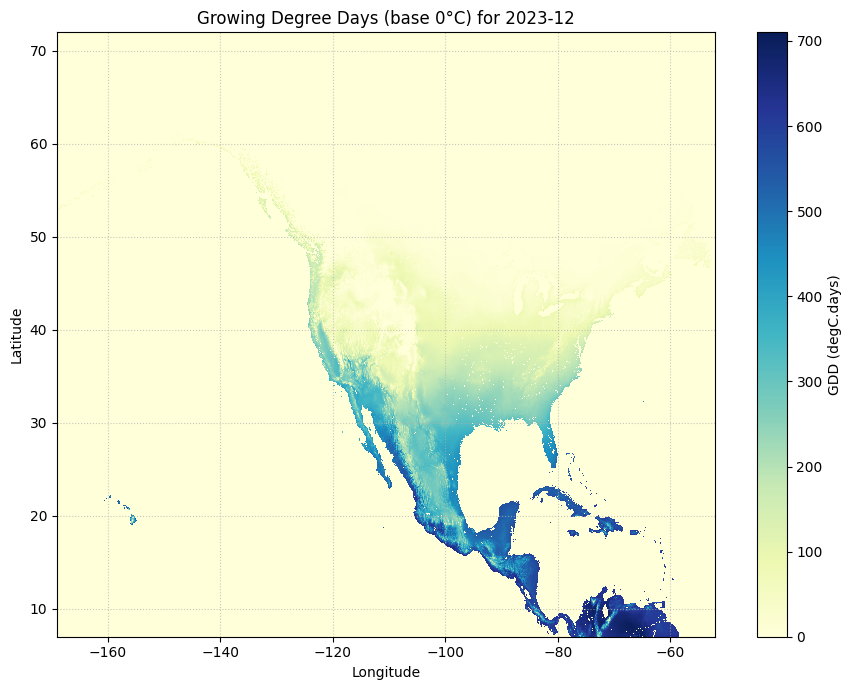

In [ ]:
# Plot Growing Degree Days
if not gdd_monthly.isnull().all().compute():
    plt.figure(figsize=(9, 7))
    gdd_monthly.isel(time=0).plot(cmap='YlGnBu', cbar_kwargs={'label': 'GDD (degC.days)'})
    plt.title(f"Growing Degree Days (base {GDD_BASE_TEMP_C}°C) for {gdd_monthly['time'].isel(time=0).dt.strftime('%Y-%m').item()}")
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("GDD result is all NaNs, skipping plot.")


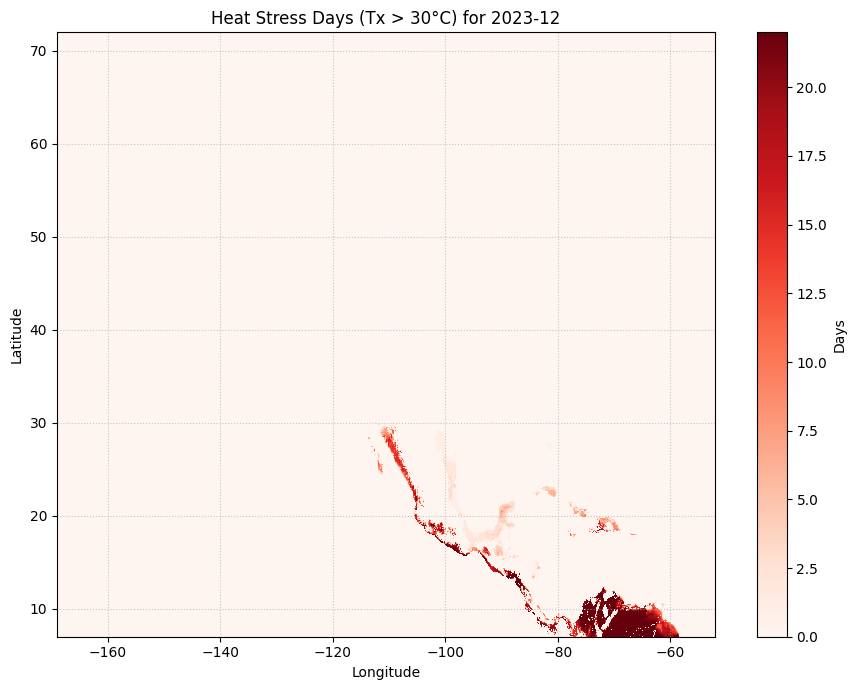

In [ ]:

# Plot Heat Stress Days
if not hsd_monthly.isnull().all().compute():
    plt.figure(figsize=(9, 7))
    hsd_monthly.isel(time=0).plot(cmap='Reds', cbar_kwargs={'label': 'Days'})
    plt.title(f"Heat Stress Days (Tx > {HSD_THRESHOLD_C}°C) for {hsd_monthly['time'].isel(time=0).dt.strftime('%Y-%m').item()}")
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print(f"HSD result is all NaNs (expected for Dec with {HSD_THRESHOLD_C}°C threshold), skipping plot.")


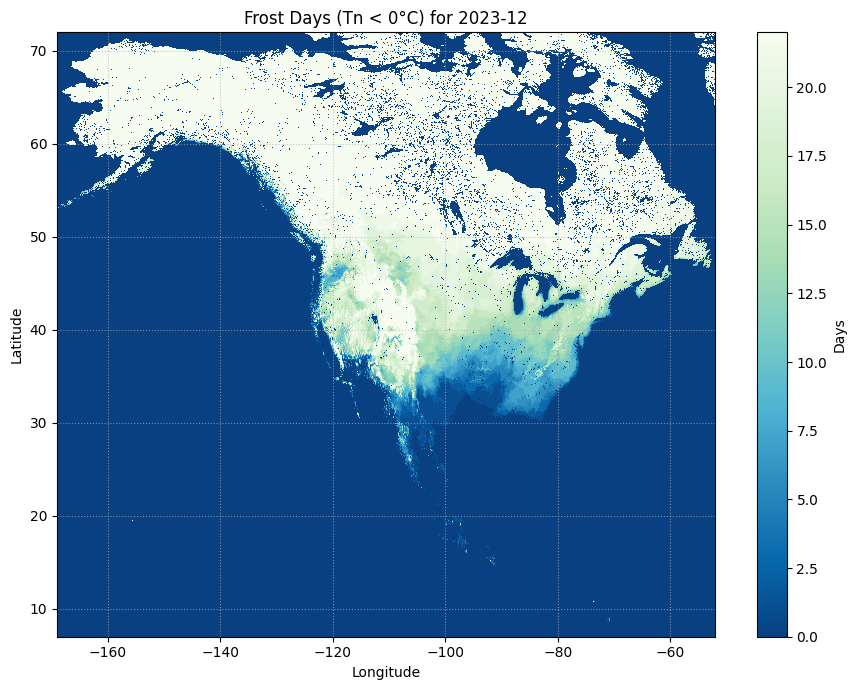


All derived values plotted (if not all NaNs).


In [ ]:

# Plot Frost Days
if not frost_monthly.isnull().all().compute():
    plt.figure(figsize=(9, 7))
    frost_monthly.isel(time=0).plot(cmap='GnBu_r', cbar_kwargs={'label': 'Days'}) # GnBu_r for reversed blues
    plt.title(f"Frost Days (Tn < {FROST_THRESHOLD_C}°C) for {frost_monthly['time'].isel(time=0).dt.strftime('%Y-%m').item()}")
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Frost Days result is all NaNs, skipping plot.")
